<a href="https://colab.research.google.com/github/danielarruda1000/geo_visao_comp/blob/main/GEO_VISAO_PROJ_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Questão 1**: Encontre o par de câmeras usando nessas imagens usando correspondência 3d 2d

**Questão 2**: faça a reconstrução 3d de um ponto (não usado na questão 1). Ou seja, vc vai definir um ponto em cada imagem e fazer a reconstrução do ponto 3d associado usando as câmeras

In [69]:
from IPython.display import Image
import matplotlib.pyplot as plt

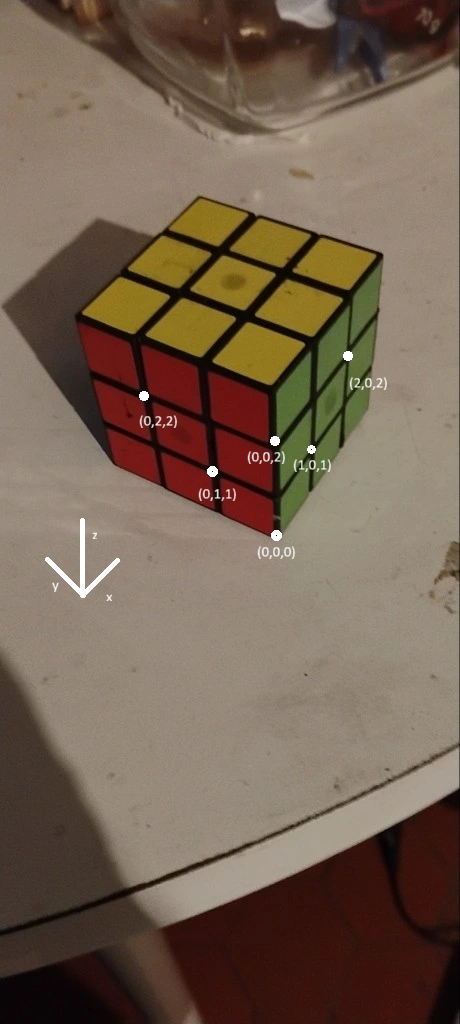

In [70]:
Image("cubo_1_marcações.png")

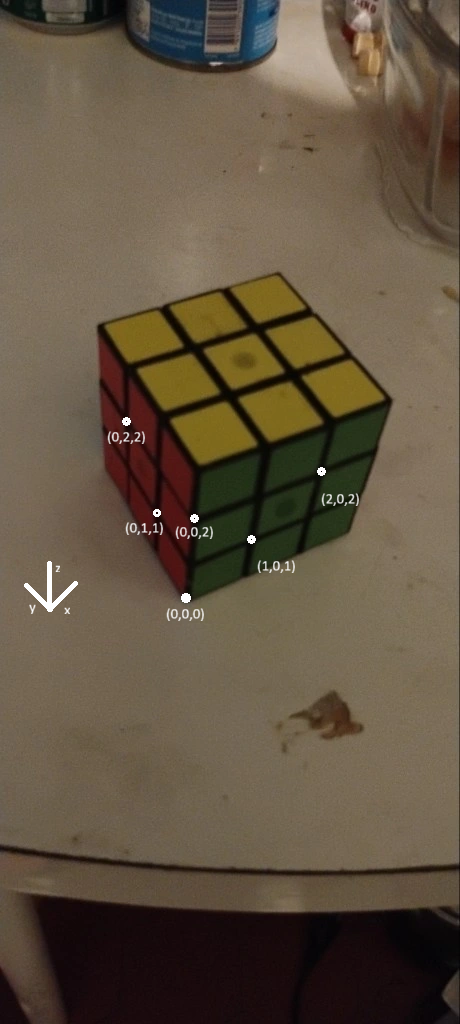

In [71]:
Image("cubo_2_marcações.png")

# Questão 1) Encontrar o par de cameras

In [99]:
import numpy as np

def achar_matriz_p_camera(points_3d, points_2d):

    n = points_3d.shape[0]
    A = []

    for i in range(n):
        X, Y, Z = points_3d[i]
        u, v = points_2d[i]

        A.append([ X, Y, Z, 1,   0, 0, 0, 0,   -u*X, -u*Y, -u*Z, -u ])
        A.append([ 0, 0, 0, 0,   X, Y, Z, 1,   -v*X, -v*Y, -v*Z, -v ])

    A = np.array(A)

    U, S, Vt = np.linalg.svd(A)
    P = Vt[-1].reshape(3, 4)

    return P / P[-1, -1]

In [100]:
# Pontos 3D
points_3d = np.array([
    #(0,0,0),
    #(0,0,2),
    #(0,0,1),
    #(0,2,1),
    (2,0,1),
    (0,2,2),

    (1,0,2),
    (2,0,2),
    (0,1,1),
    (0,2,2),

], dtype=float)

# Pontos 2D da foto 1
points_2d_foto_1 = np.array([
  #(276, 535),
  #(276, 443),
  #(274, 494),
  #(208, 420),
  (344,408),
  (208,422),

  #Face verde
  (312, 450),
  (347, 353),
  #Face vermelha
  (215, 472),
  (146, 396)
], dtype=float)

# Pontos 2D da foto 2
points_2d_foto_2 = np.array([
  #(186, 598),
  #(194, 518),
  #(190, 560),
  #(158, 467),
  (307, 517),
  (159,471),

  # Face verde
  (250, 539),
  (320, 472),
  # Face vermelha
  (157, 513),
  (125, 421)
], dtype=float)

P1 = achar_matriz_p_camera(points_3d, points_2d_foto_1)
P2 = achar_matriz_p_camera(points_3d, points_2d_foto_2)

print("Matriz de câmera P1:\n", P1)
print()
print("Matrix de câmera P2:\n", P2)

Matriz de câmera P1:
 [[-8.97591595e+02 -7.78314769e+02  6.70814769e+02  2.15000000e+02]
 [-1.19321399e+03 -1.07187475e+03  8.35874745e+02  4.72000000e+02]
 [-2.79977560e+00 -2.45603835e+00  1.95603835e+00  1.00000000e+00]]

Matrix de câmera P2:
 [[-5.38205353e+02 -4.55642826e+02  3.77142826e+02  1.57000000e+02]
 [-1.04792058e+03 -9.26140851e+02  6.69640851e+02  5.13000000e+02]
 [-2.00833699e+00 -1.75032909e+00  1.25032909e+00  1.00000000e+00]]


In [101]:
# Verificar se P está bem calculado

# Foto 1 -> Ponto (0,0,1) = (274, 494) | Ponto (0,2,1) = (208, 420)
ponto_rp2 = P1 @ np.array([0,0,0, 1])
#ponto_2_rp2 = P1 @ np.array([0,2,1,1])

# Coordenada homogenea
x = round(ponto_rp2[0] / ponto_rp2[2])
y = round(ponto_rp2[1] / ponto_rp2[2])

#x_2 = round(ponto_2_rp2[0] / ponto_2_rp2[2])
#y_2 = round(ponto_2_rp2[1] / ponto_2_rp2[2])

print('Foto 1:')
print('Ponto [0,0,0] = ', x, ',', y)
#print('Ponto [0,2,1] = ', x_2, ',', y_2)

Foto 1:
Ponto [0,0,0] =  215 , 472


In [105]:
# Foto 2 -> Ponto (0,0,1) = (190, 560) | Ponto (0,2,1) = (158, 467)
ponto_rp2 = P2 @ np.array([0,0,0,1])
ponto_2_rp2 = P2 @ np.array([0,2,1,1])

# Coordenada homogenea
x = round(ponto_rp2[0] / ponto_rp2[2])
y = round(ponto_rp2[1] / ponto_rp2[2])

x_2 = round(ponto_2_rp2[0] / ponto_2_rp2[2])
y_2 = round(ponto_2_rp2[1] / ponto_2_rp2[2])

print('\nFoto 2:')
print('Ponto [0,0,1] = ', x, ',', y)
#print('Ponto [0,2,1] = ', x_2, ',', y_2)


Foto 2:
Ponto [0,0,1] =  157 , 513


# Questão 2

In [109]:
def triangular_duas_views(P1, x1, P2, x2):
    u1, v1 = x1
    u2, v2 = x2

    A = np.vstack([
        u1 * P1[2, :] - P1[0, :],
        v1 * P1[2, :] - P1[1, :],
        u2 * P2[2, :] - P2[0, :],
        v2 * P2[2, :] - P2[1, :]
    ])

    _, _, Vt = np.linalg.svd(A)
    Xh = Vt[-1]
    X = Xh[:3] / Xh[3]

    return X, Xh

def reprojection_error(P, Xh, uv):
    if Xh.shape[0] == 3:
        Xh = np.hstack([Xh, 1.0])
    proj = P @ Xh
    proj = proj / proj[2]
    u_proj, v_proj = proj[0], proj[1]
    u, v = uv
    print("u_proj:", u_proj)
    print("v_proj:", v_proj)
    err = np.sqrt((u_proj - u)**2 + (v_proj - v)**2)
    return err

In [110]:
# Ponto 3D (0,0,3) na imagem 1 = (272, 390)
# Ponto 3D (0,0,3) na imagem 2 = (199, 470)

X, Xh = triangular_duas_views(P1, (272,390), P2, (199,470))

print("X 3D:", X)
print("Reproj err img1:", reprojection_error(P1, Xh, (272,390)))
print("Reproj err img2:", reprojection_error(P2, Xh, (199,470)))

X 3D: [5.41781097e-12 2.00000000e+00 2.00000000e+00]
u_proj: 278.0041928721174
v_proj: 331.67295597484275
Reproj err img1: 58.63526581126939
u_proj: 186.09680365296805
v_proj: 509.662100456621
Reproj err img2: 41.70820888747385
